In [16]:
import numpy as np
import time

import sys

module_dir = '..'
sys.path.append(module_dir)

import matplotlib.pyplot as plt
from src import IOFunctions

IO = IOFunctions.IO_Functions()
from src import PlottingFunctions

plots = PlottingFunctions.Plotter()

import os
from copy import copy

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()
import pandas as pd

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from sklearn.cluster import KMeans

from scipy.stats import mode

dyes_9 = np.array(
    [
        "#c55d88",
        "#b45ac2",
        "#6e7ecc",
        "#4bb194",
        "#69b44c",
        "#6e7f38",
        "#c4aa42",
        "#c27945",
        "#d04c41",
    ]
)

from scipy.spatial.distance import cdist

In [2]:
folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20241025/data/"
analysis = pd.read_csv(
    os.path.join(
        folder,
        "Test_9colourPAINT_linkerlength_pixelsize69nm_40nm_spotlocations_withclusteranalysis.csv",
    )
)
real_spot_locations = pd.read_csv(
    os.path.join(
        folder, "Test_9colourPAINT_linkerlength_pixelsize69nm_40nm_spotlocations.csv"
    )
)

In [103]:
analysis['xc_err'] = 2/np.sqrt(analysis.A)
analysis['yc_err'] = 2/np.sqrt(analysis.A)

In [286]:
subset = np.random.choice(analysis.index.to_numpy(), 15023)

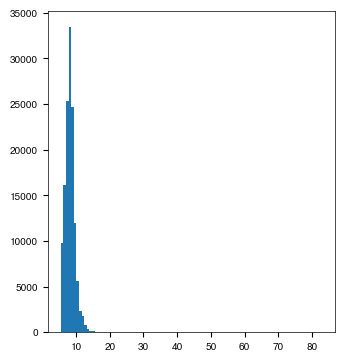

In [275]:
plt.hist(analysis.xc_err*69, 100);
plt.show()

In [276]:
from Camera_QE import getpixelefficiency

gpe = getpixelefficiency.GPE()
R, G, B, wavelength = gpe.getpixelefficiency("Camera_QE/CS505CU_QE.csv")

absolute_QYs = np.vstack([R, G, B])

dye_names = np.array(
    [
        "ATTO488",
        "AF514",
        "Cy3B",
        "ATTO565",
        "ATTO590",
        "ATTO610",
        "ATTO647N",
        "AF700",
        "ATTO740",
    ]
)

folder = "Spectra/Em/Dyes/"
emission_spectra = np.sort(os.listdir(folder))
dyes = np.zeros([len(dye_names), len(wavelength)])
mean_wavelength = np.zeros(len(dye_names))

for i, dye in enumerate(dye_names):
    file = np.sort([e for e in emission_spectra if dye in e])[0]
    skip_rows = 1
    if "ATTO" in dye:
        separator = "\t"
    else:
        separator = ","

    data = pl.read_csv(
        os.path.join(folder, file), separator=separator, skip_rows=skip_rows
    )
    d_wl = data[:, 0].to_numpy()
    d_em = data[:, 1].to_numpy()
    dye_spectrum = np.interp(x=wavelength, xp=d_wl, fp=d_em)
    dye_spectrum = dye_spectrum / np.sum(dye_spectrum)
    dyes[i, :] = dye_spectrum
    mean_wavelength[i] = np.trapz(y=dye_spectrum * wavelength, x=wavelength)

dye_pixel_efficiency = np.dot(dyes, absolute_QYs.T)
dye_pixel_efficiency = dye_pixel_efficiency.T / np.sum(dye_pixel_efficiency, axis=1)
dye_pixel_efficiency = dye_pixel_efficiency.T

ModuleNotFoundError: No module named 'Camera_QE'

In [59]:
from src import render

In [288]:
analysis_subset = analysis.iloc[subset, :]

In [ ]:
analysis['cluster_n'] == 4

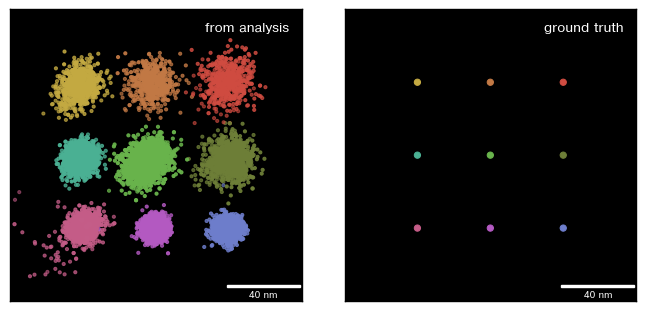

In [290]:
frame_number = 20000
pixel_size = 69


cs = np.zeros_like(analysis_subset["B"].to_numpy(), dtype="object")
for i in np.arange(len(cs)):
    cs[i] = colours_of_cluster[analysis_subset["cluster_n"].to_numpy()[i]]

fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1, 1])

alpha = 1 / np.abs(analysis_subset["sigma"].to_numpy())
alpha = alpha / np.max(alpha)

axs[0] = plotter.image_plot(
    axs=axs[0],
    data=np.zeros([4000, 4000]),
    pixelsize=1,
    scalebarlabel="40 nm",
    scalebarsize=40,
    vmin=0,
    vmax=1,
    cbar='off'

)
axs[0] = plotter.scatter_plot(
    axs=axs[0],
    x=pixel_size * analysis_subset["yc"].to_numpy(),
    y=pixel_size * analysis_subset["xc"].to_numpy(),
    alpha=alpha,
    facecolor=cs,
    edgecolor=None,
    xaxislabel="",
    yaxislabel="",
    rasterized=True,
)

axs[0].set_ylim([1300, 1460])
axs[0].set_xlim([1300, 1460])
axs[0].scatter(0, 0, alpha=0, label="from analysis")
axs[0].legend(loc="upper right", frameon=False, fontsize=10, labelcolor="white")


axs[0].set_xlabel("")
axs[0].set_ylabel("")

axs[1] = plotter.image_plot(
    axs=axs[1],
    data=np.zeros([4000, 4000]),
    pixelsize=1,
    scalebarlabel="40 nm",
    scalebarsize=40,
    vmin=0,
    vmax=1,
    cbar='off'
)
axs[1] = plotter.scatter_plot(
    axs=axs[1],
    x=real_spot_locations["x_nm"].to_numpy(),
    y=real_spot_locations["y_nm"].to_numpy(),
    facecolor=dyes_9,
    edgecolor=None,
    s=20,
    xaxislabel="",
    yaxislabel="",
    rasterized=True,
)

axs[1].scatter(0, 0, alpha=0, label="ground truth")
axs[1].legend(loc="upper right", frameon=False, fontsize=10, labelcolor="white")

axs[1].set_ylim([1300, 1460])
axs[1].set_xlim([1300, 1460])

savefolder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/hypothetical_PAINT/"
plt.savefig(
    os.path.join(savefolder, "exemplar_15023locs.svg"), format="svg", dpi=600
)
plt.show()

In [57]:
colours_of_cluster = copy(dyes_9)
colours_of_cluster[5] = copy(dyes_9[0])
colours_of_cluster[2] = copy(dyes_9[3])
colours_of_cluster[3] = copy(dyes_9[2])
colours_of_cluster[6] = copy(dyes_9[5])
colours_of_cluster[7] = copy(dyes_9[6])
colours_of_cluster[0] = copy(dyes_9[7])

In [293]:
colour_0 = analysis_subset[analysis_subset['cluster_n'] == 7]
_, image_c0 = render.render(colour_0.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian")

colour_1 = analysis_subset[analysis_subset['cluster_n'] == 1]
_, image_c1 = render.render(colour_1.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian")

colour_2 = analysis_subset[analysis_subset['cluster_n'] == 3]
_, image_c2 = render.render(colour_2.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian")

colour_3 = analysis_subset[analysis_subset['cluster_n'] == 2]
_, image_c3 = render.render(colour_3.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian")

colour_4 = analysis_subset[analysis_subset['cluster_n'] == 4]
_, image_c4 = render.render(colour_4.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian")

colour_5 = analysis_subset[analysis_subset['cluster_n'] == 6]
_, image_c5 = render.render(colour_5.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian")

colour_6 = analysis_subset[analysis_subset['cluster_n'] == 5]
_, image_c6 = render.render(colour_6.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian")

colour_7 = analysis_subset[analysis_subset['cluster_n'] == 0]
_, image_c7 = render.render(colour_7.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian")

colour_8 = analysis_subset[analysis_subset['cluster_n'] == 8]
_, image_c8 = render.render(colour_8.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian")

In [271]:
image_c8.shape

(352, 352)

In [272]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

In [183]:
# Define your custom color palette
custom_colors = [
   'black', # first color
   '#c55d88' # last color
]

# Create a ListedColormap
custom_pink = LinearSegmentedColormap.from_list("custom_gradient", custom_colors)


# Define your custom color palette
custom_colors = [
   'black', # first color
   '#b45ac2' # last color
]

# Create a ListedColormap
custom_purple = LinearSegmentedColormap.from_list("custom_gradient", custom_colors)


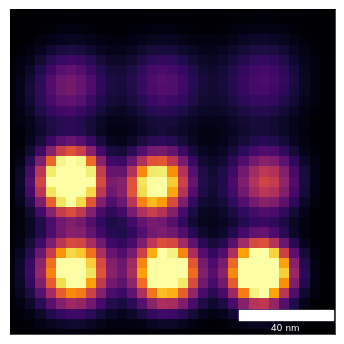

In [294]:
fig, axs = plotter.one_column_plot()

overall_image = image_c0+image_c1+image_c2+image_c3+image_c4+image_c5+image_c6+image_c7+image_c8
axs = plotter.image_plot(axs, overall_image.T, vmax=np.percentile(overall_image, 99.96), cmap='inferno', scalebarsize=40, pixelsize=69/16, scalebarlabel='40 nm', cbar='off')
axs.set_xlim([19*16, 21*16])
axs.set_ylim([19*16, 21*16])

savefolder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/hypothetical_PAINT/"
plt.savefig(
    os.path.join(savefolder, "Super_res_image_15023locs.svg"), format="svg", dpi=1200
)


In [295]:
colour_0 = analysis_subset[analysis_subset['cluster_n'] == 7]
_, image_c0 = render.render(colour_0.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian", min_blur_width=1.2)

colour_1 = analysis_subset[analysis_subset['cluster_n'] == 1]
_, image_c1 = render.render(colour_1.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian", min_blur_width=1.2)

colour_2 = analysis_subset[analysis_subset['cluster_n'] == 3]
_, image_c2 = render.render(colour_2.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian", min_blur_width=1.2)

colour_3 = analysis_subset[analysis_subset['cluster_n'] == 2]
_, image_c3 = render.render(colour_3.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian", min_blur_width=2.3)

colour_4 = analysis_subset[analysis_subset['cluster_n'] == 4]
_, image_c4 = render.render(colour_4.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian", min_blur_width=2.3)

colour_5 = analysis_subset[analysis_subset['cluster_n'] == 6]
_, image_c5 = render.render(colour_5.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian", min_blur_width=2.3)

colour_6 = analysis_subset[analysis_subset['cluster_n'] == 5]
_, image_c6 = render.render(colour_6.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian", min_blur_width=2.3)

colour_7 = analysis_subset[analysis_subset['cluster_n'] == 0]
_, image_c7 = render.render(colour_7.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian", min_blur_width=2.3)

colour_8 = analysis_subset[analysis_subset['cluster_n'] == 8]
_, image_c8 = render.render(colour_8.to_records(index=False), oversampling=16, viewport=((0, 0), (22, 22)), blur_method="gaussian", min_blur_width=2.3)

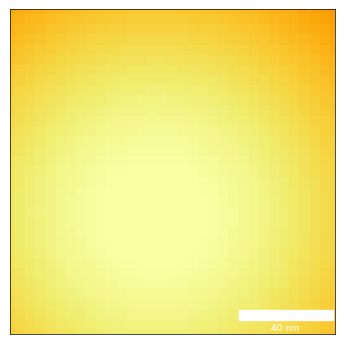

In [296]:
fig, axs = plotter.one_column_plot()

overall_image = image_c0+image_c1+image_c2+image_c3+image_c4+image_c5+image_c6+image_c7+image_c8
axs = plotter.image_plot(axs, overall_image.T, vmax=np.percentile(overall_image, 99.96), cmap='inferno', scalebarsize=40, pixelsize=69/16, scalebarlabel='40 nm', cbar='off')
axs.set_xlim([19*16, 21*16])
axs.set_ylim([19*16, 21*16])

savefolder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/hypothetical_PAINT/"
plt.savefig(
    os.path.join(savefolder, "NonSuper_res_image_15023locs.svg"), format="svg", dpi=1200
)
